## Machine Learning Model for Predicting Syriatel Customer Churn


### Project Overview

This project aims to support SyriaTel in addressing customer churn by developing a classification model that predicts whether a customer is likely to stop doing business with the company in the near future. By accurately predicting customer churn, SyriaTel can take early action to address customer dissatisfaction, implement targeted retention measures, and strengthen customer loyalty. Ultimately, this will help reduce churn rates, improve customer satisfaction, and enhance the company’s competitive position in the market.

### Business Understanding

SyriaTel is a telecommunications company that provides mobile network services in Syria. Recently, the company has experienced rising customer attrition rates, which pose a serious threat to revenue stability and market share. Customer churn is a metric showing when a subscriber or a regular customer cancels his subscription or stops doing business with a company. This challenge highlights the need to better understand the key factors contributing to customer churn. Identifying the drivers of customer defection and developing proactive retention strategies is essential for maintaining profitability and remaining competitive in the telecommunications industry.

### Problem Statement:
As SyriaTel navigates a competitive telecommunications landscape, the increasing attrition of
customers poses a significant challenge to its growth and profitability. By analyzing the
factors contributing to churn, SyriaTel can adopt proactive measures to enhance customer
satisfaction and loyalty, ultimately improving retention rates thereby ensuring sustained
profitability in a competitive market.
### Objectives:
1. Identify Churn Patterns: Analyze customer data to uncover patterns associated with
churn.
2. Develop a Customer Churn Prediction Model: Design a binary classification model
employing machine learning techniques to estimate the probability of a customer
discontinuing services. The model should be trained on past customer data and
evaluated with suitable performance metrics such as accuracy, precision, recall, and
F1-score.
3. Deliver Practical Recommendations: Provide practical recommendations and insights
derived from analysis and model outcomes.

### Stakeholder
The stakeholder is the Syriatel company including the business and customer retention team

### Data Understanding
The Customer Churn in Telecom’s dataset from Kaggle contains information about customer activity and whether or not they canceled their subscription with the Telecom firm. The goal of this dataset is to develop predictive models that can help the telecom business reduce the amount of money lost due to customers who don’t stick around for very long.

The dataset contains 3333 entries and 21 columns, including information about the state, account length, area code, phone number, international plan, voice mail plan, number of voice mail messages, total day minutes, total day calls, total day charge, total evening minutes, total evening calls, total evening charge, total night minutes, total night calls, total night charge, total international minutes, total international calls, total international charge, customer service calls and churn.



### 1. Load data

In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV

In [10]:
# Load the dataset
customer_data = pd.read_csv('SyriaTel_Churn_Dataset.csv')
# Display the first few rows of the dataset
customer_data.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [11]:
# Preview the dataset's shape and data types
print(customer_data.shape)
print(customer_data.info())

(3333, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 

### 2. Data Cleaning

In [12]:
# Check for missing values
print(customer_data.isnull().sum())


state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64


In [13]:
# Check for duplicates
print(customer_data.duplicated().sum())

0


##### Our dataset has no duplicates or missing values. We can go ahead and do data exploration

### 3. Exploratory Data analysis

Our target variable is 'Churn', which indicates whether a customer has churned (1) or not (0). 
We will analyze the distribution of this target variable to understand the balance of our dataset.

In [14]:
# Check target variable distribution
print(customer_data['churn'].value_counts())

churn
False    2850
True      483
Name: count, dtype: int64


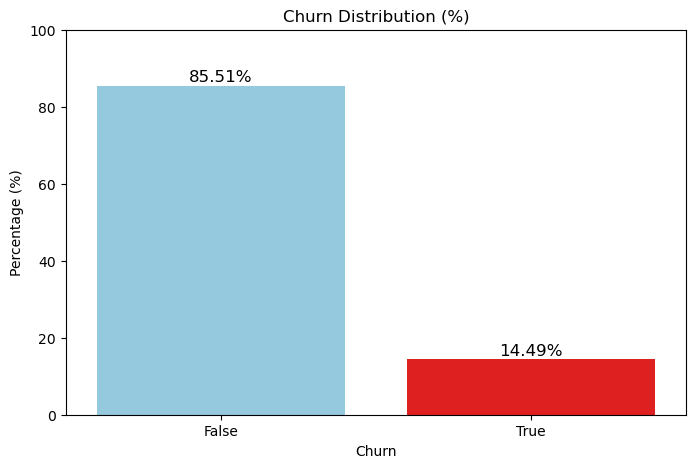

85.51% of the data belongs to the False class while 14.49% belongs to the true class, this indicates that the dataset is imbalanced.


In [15]:
# Calculate percentages
churn_percent = (customer_data['churn'].value_counts(normalize=True) * 100).reset_index()
churn_percent.columns = ['churn', 'percent']

# Plot bar chart
plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=churn_percent,
    x='churn',
    y='percent',
    hue='churn',
    palette={False: 'skyblue', True: 'red'},
    legend=False
)

# Add percentage labels
for i, v in enumerate(churn_percent['percent']):
    ax.text(i, v + 1, f"{v:.2f}%", ha='center', fontsize=12)

plt.title("Churn Distribution (%)")
plt.xlabel("Churn")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.show()
print(f"85.51% of the data belongs to the False class while 14.49% belongs to the true class, this indicates that the dataset is imbalanced.")

In [16]:
# Get summary statistics for numerical features
customer_data.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


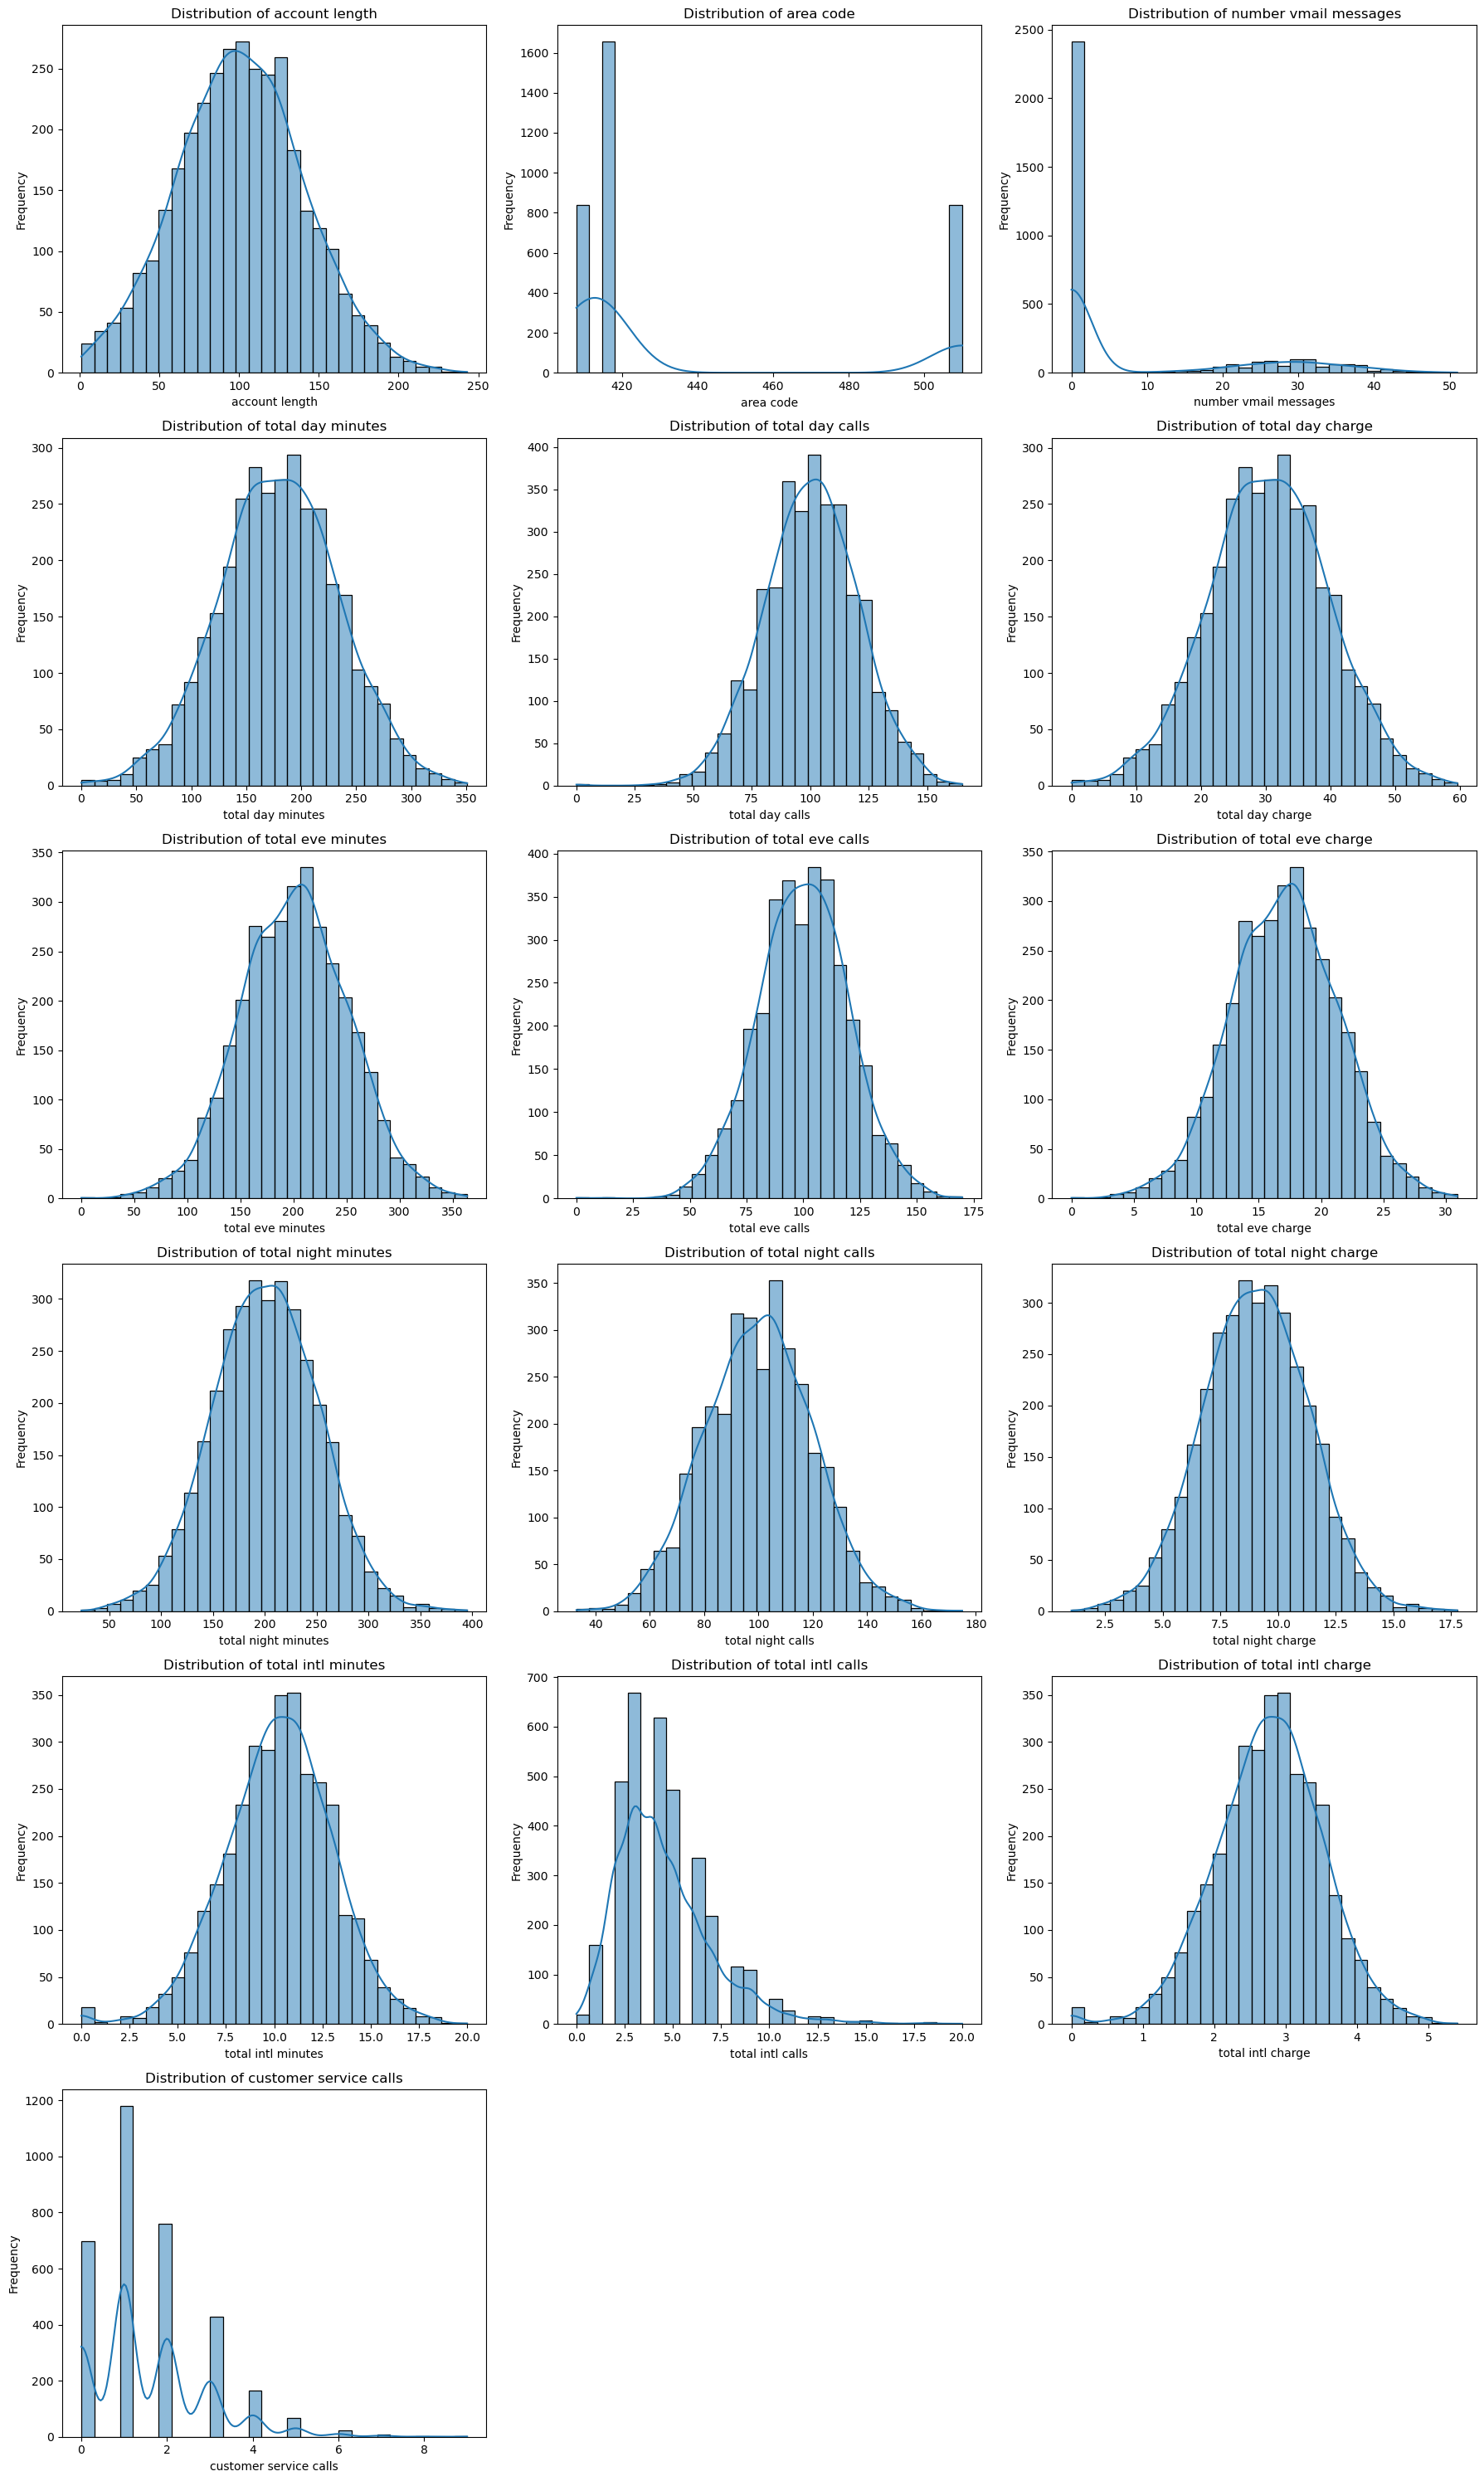

In [17]:
# Plotting distributions of numerical features, 
# we will use histograms with KDE (Kernel Density Estimate) to
# visualize the distribution of each numerical feature in the dataset.

# Numerical features
import math

numerical_features = customer_data.select_dtypes(include=[np.number]).columns.tolist()

# subplot layout
n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(numerical_features):
    sns.histplot(customer_data[feature], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Some features show a right-skewed distribution, while others appears to be more normally distributed. 
##### This information will help us decide on potential transformations or scaling methods for these features during preprocessing.

### Bivariate Analysis
Bivariate analysis involves analyzing the relationship between two variables. For this project, I examine the relationship between each feature and the target variable (customer churn) to understand how they are related.

Here, I am doing some analysis of the customer churning in relation to international plan and voice mail plan. I am trying to understand whether there are correlations between the categorical columns and the customer churning rate.

C:\Users\Stephen\AppData\Local\Temp\ipykernel_26400\2444976805.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
C:\Users\Stephen\AppData\Local\Temp\ipykernel_26400\2444976805.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)


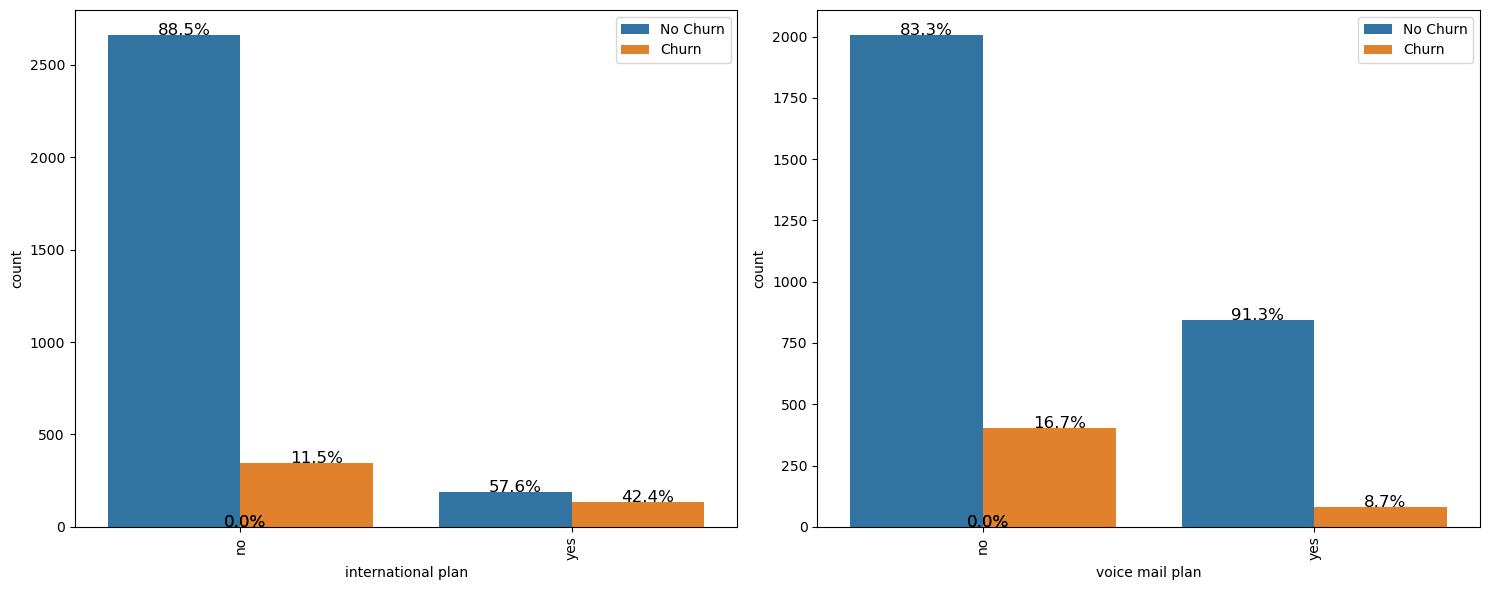

In [18]:
categoric_cols = ['international plan','voice mail plan']

fig, axes = plt.subplots(nrows=1, ncols=len(categoric_cols), figsize=(15, 6))

for i, col in enumerate(categoric_cols):
    ax = sns.countplot(x=col, hue="churn", data=customer_data, order=customer_data[col].value_counts().iloc[0:15].index, ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
    handles, labels = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, ['No Churn', 'Churn'], loc="upper right")

    # Calculate the total number of observations within each group
    totals = customer_data.groupby(col)["churn"].count().values

    # Iterate over the rectangles in the plot
    for j, p in enumerate(ax.patches):
        # Calculate the percentage of observations in each group
        percentage = '{:.1f}%'.format(100 * p.get_height()/totals[j % 2])
        # Add text annotations with the calculated percentages
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), size=12)

plt.tight_layout()
plt.show()

For the international plan, a higher proportion of customers who subscribed to the plan churned (42.4%) compared to those who did not subscribe (11.5%). This suggests that subscribing to the international plan may be associated with a higher likelihood of churning. This could indicate that there are issues associated with the international plans that could be making the plan unsatisfactory to the client.

For the voice mail plan, a lower proportion of customers who subscribed to the plan churned (8.7%) compared to those who did not subscribe (16.7%). This suggests that subscribing to the voice mail plan may be associated with a lower likelihood of churning.

### Correlations between different features and the target
Visualize the correlations between different features and customer churning. Here, I am trying to understand how each feature might be contributing to customer churning. I use pairplots for this case.

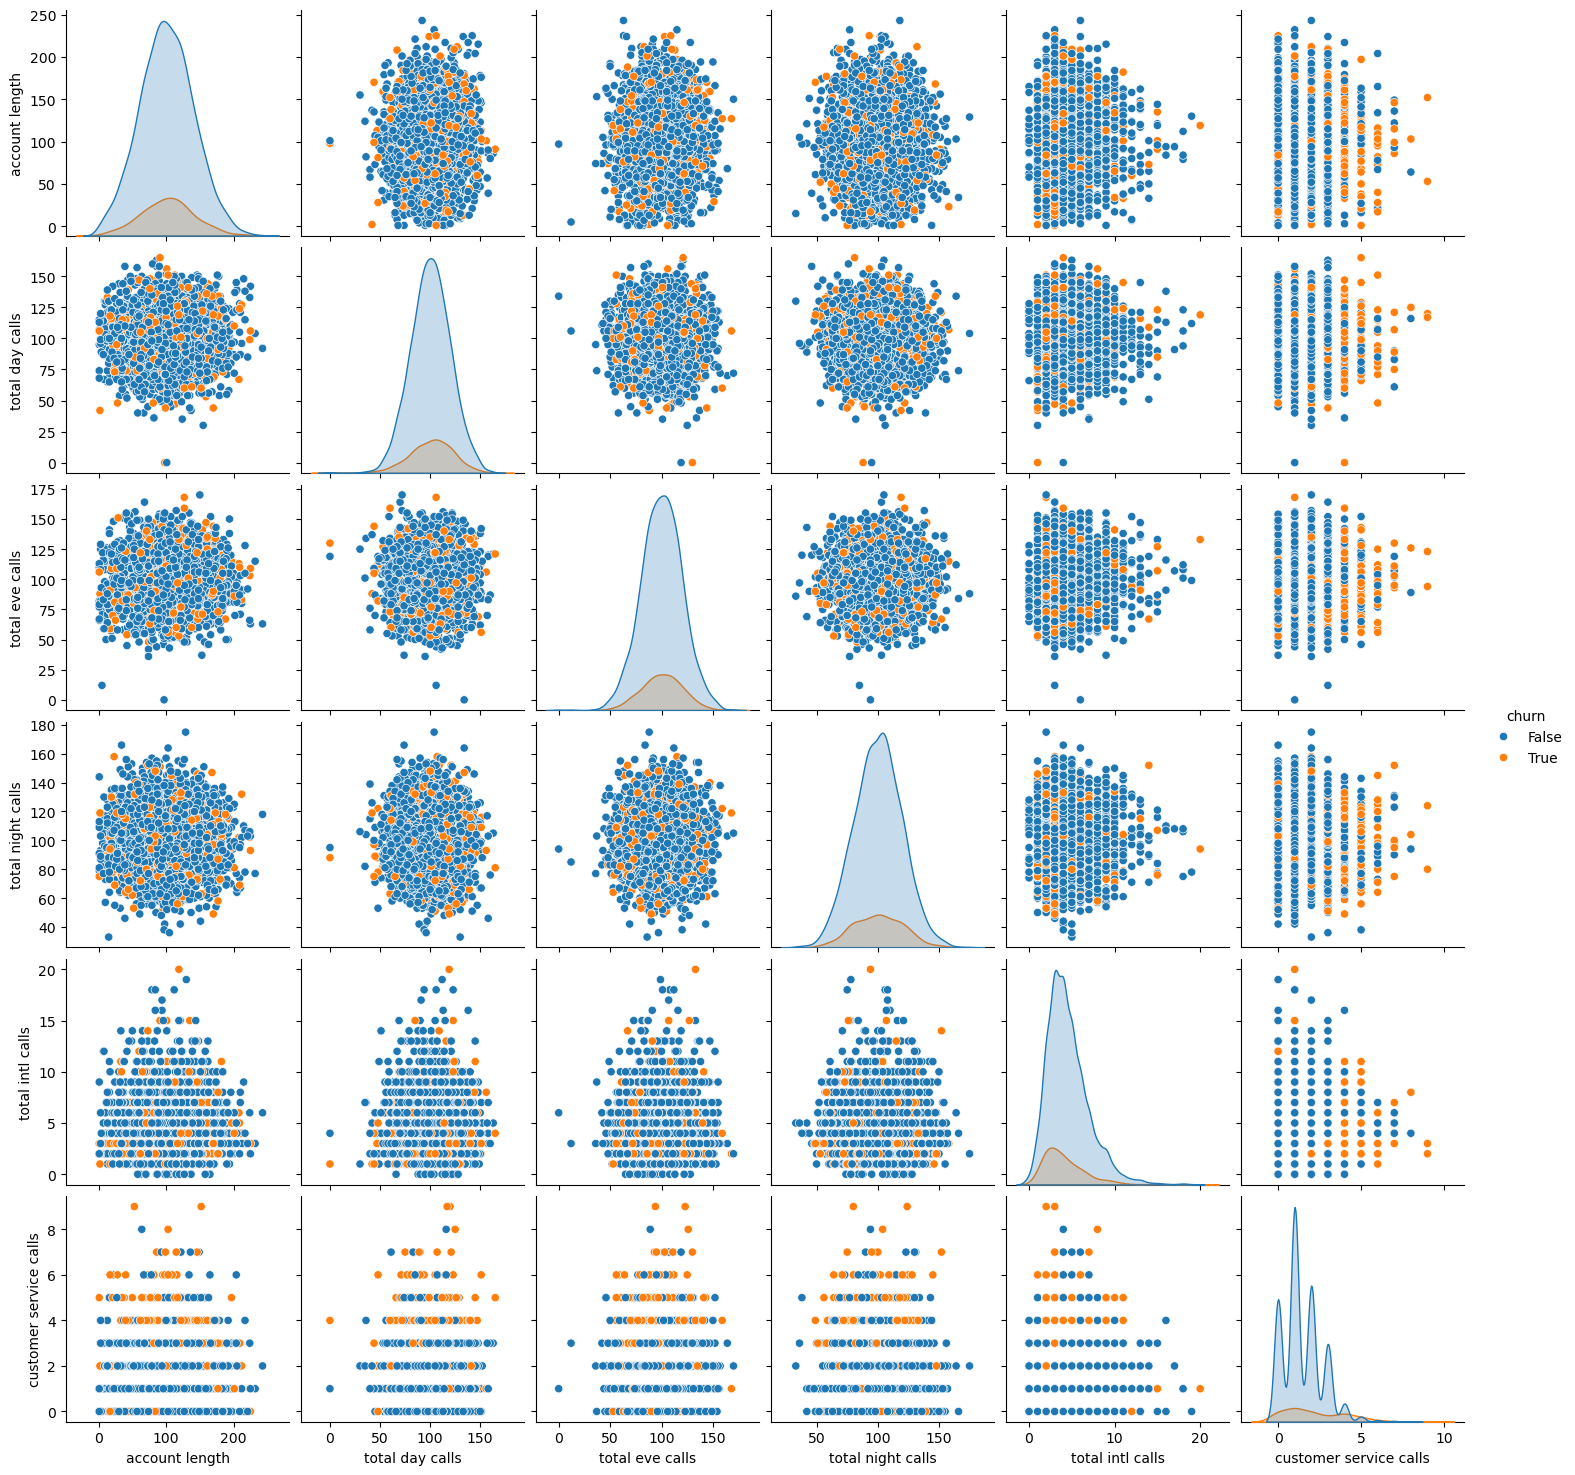

In [19]:
#plotting pairplots for numeric variables
data_temp = customer_data[["account length","total day calls","total eve calls","total night calls",
                "total intl calls","customer service calls","churn"]]
sns.pairplot(data_temp, hue="churn",height=2.5);
plt.show();

There seems to be strong relationship between customer service calls and true churn values. After 4 calls, customers are a lot more likely to discontinue their service.

Besides, most customer calls are are associated with disatisfaction with customer service. At this point more than 4 customer calls indicate that it takes long for their issues to be addressed, and thus a possibility of them leaving increases.

### Multi-variate Analysis
Multivariate analysis involves analyzing the relationship between multiple variables simultaneously. In this case, I explore the relationship between multiple features and the target variable (customer churn) to understand how they are related when considered together.

I use a correlation matrix to identify the correlation between different variables in the dataset.

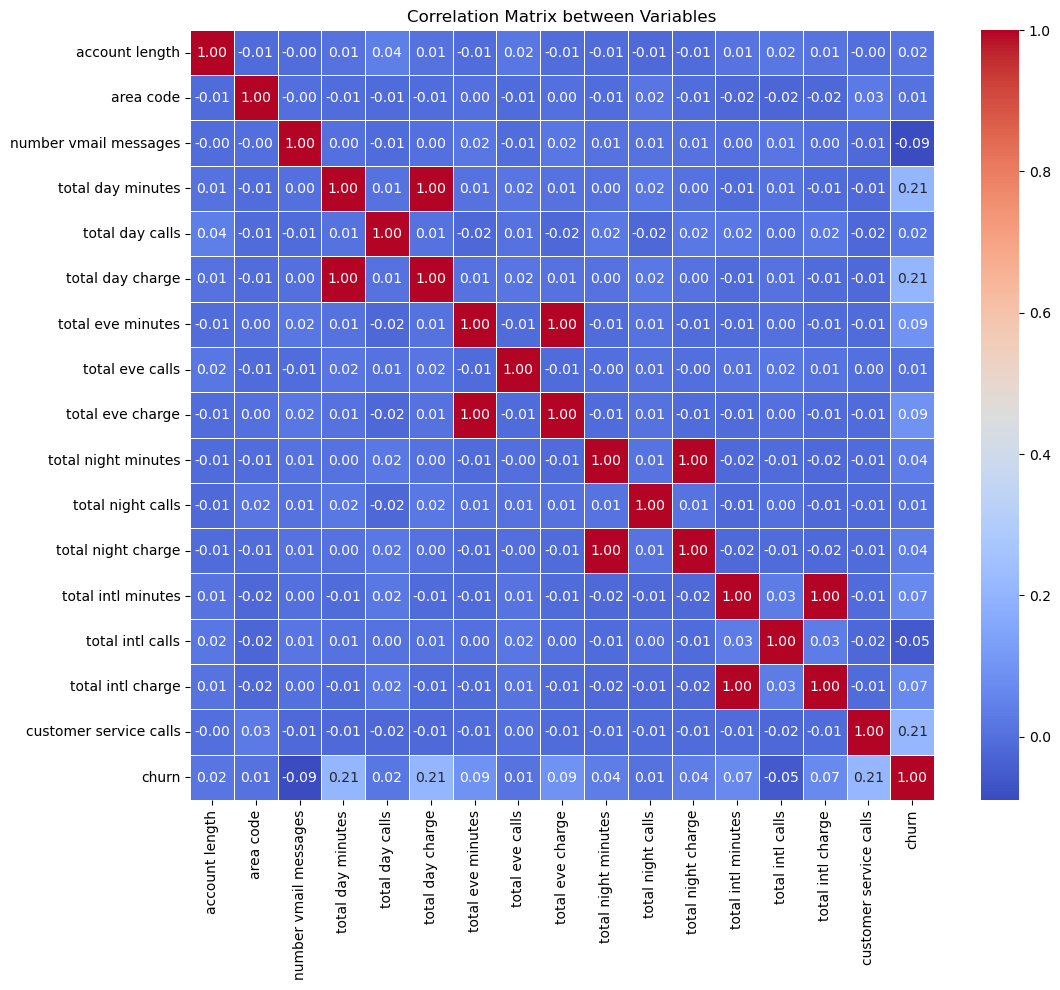

In [20]:
# Calculate the correlation matrix
corr_matrix = customer_data.corr(numeric_only=True)

# Generate the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix between Variables')
plt.show();

* There is a very low correlation between most features.
* However, there is a perfect positive correlation between total evening charge and total evening minutes, total day charge and total day minutes, total night charge and total night minutes, and total international charge and total international minutes. This is expected since the charge of a call depends on the length of the call in minutes. One correlated variable will have to be dropped from each pair to handle multicollinearity.
* total day minutes, total day charge and customer service calls have a weak positive correlation with churn.
* The other features have a negligible correlation with churn, approximately 0.

### Data preparation for Machine Learning

The dataset contains both categorical and numerical features, and some columns must be transformed into a format that can be used effectively by machine learning models during the modeling stage.

To achieve this, one-hot encoding will be applied to categorical columns with object data types, converting them into numerical binary variables (0s and 1s).

The data will then be divided into training and testing sets. The training set will be used to fit the models, while the test set will be used to evaluate their performance. In addition, cross-validation will be applied to ensure the models generalize well and reduce the risk of overfitting.

Finally, features that contribute little or no predictive value will be removed using regularization techniques such as Ridge and Lasso regression, which help identify and reduce the influence of irrelevant variables.

### Remove columns with multicollinearity
Multicollinearity makes it hard for the model to determine the true effect of each predictor because they “move together”.

In [21]:
# Multicollinearity can lead to issues in model performance, especially for linear models. 
# Check pairs with collinearity > 0.75
df = customer_data.corr(numeric_only=True).abs().stack().reset_index().sort_values(0, ascending=False)
df['pairs'] = list(zip(df.level_0, df.level_1))
df.set_index(['pairs'], inplace = True)
df.drop(columns=['level_1', 'level_0'], inplace = True)
df.columns = ['cc']
df.drop_duplicates(inplace=True)
df[(df.cc>.75) & (df.cc<1)]

,cc
pairs,
"(total day minutes, total day charge)",1.000000
"(total eve charge, total eve minutes)",1.000000
"(total night charge, total night minutes)",0.999999
"(total intl minutes, total intl charge)",0.999993


In [22]:
# Remove highly correlated features
customer_data = customer_data.drop(columns = ['total day charge', 'total eve charge', 'total night charge', 'total intl charge'])
customer_data.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total eve minutes',
       'total eve calls', 'total night minutes', 'total night calls',
       'total intl minutes', 'total intl calls', 'customer service calls',
       'churn'],
      dtype='object')

In [23]:
# Drop the 'phone number' column as it is not relevant for prediction
customer_data = customer_data.drop(columns=['phone number'])

In [24]:
#select predictor and target variables
y = customer_data['churn']
X = customer_data.drop(columns=['churn'])

In [25]:
# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100)

In [26]:
# Check the X_train and y_train shapes to confirm the split
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2666, 15)
y_train shape: (2666,)


In [27]:
# Preview X_train.
X_train.head()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
3183,KY,95,510,no,no,0,157.3,116,197.5,77,128.2,111,8.4,4,2
2131,OH,52,408,no,yes,31,142.1,77,193.0,97,253.4,88,11.0,4,1
1636,MN,65,510,no,yes,29,158.1,104,322.2,81,210.0,96,8.9,6,1
3271,WI,62,415,no,no,0,86.3,84,238.7,99,238.4,79,12.5,1,2
2295,OR,190,415,no,no,0,142.9,96,177.9,96,113.3,117,6.6,4,0


### Transform Categorical variables

In [28]:
# one-hot encode the categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


In [29]:
# Check the encoded feature names to confirm the one-hot encoding
X_train.head()

,account length,area code,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,...,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,international plan_yes,voice mail plan_yes
3183,95,510,0,157.3,116,197.5,77,128.2,111,8.4,...,False,False,False,False,False,False,False,False,False,False
2131,52,408,31,142.1,77,193.0,97,253.4,88,11.0,...,False,False,False,False,False,False,False,False,False,True
1636,65,510,29,158.1,104,322.2,81,210.0,96,8.9,...,False,False,False,False,False,False,False,False,False,True
3271,62,415,0,86.3,84,238.7,99,238.4,79,12.5,...,False,False,False,False,False,True,False,False,False,False
2295,190,415,0,142.9,96,177.9,96,113.3,117,6.6,...,False,False,False,False,False,False,False,False,False,False


### SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) is a popular technique used to address class imbalance in datasets. 
It works by generating synthetic samples for the minority class, 
which helps to balance the class distribution and improve the performance of machine learning models.

In [30]:
#SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=100)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

c:\Users\Stephen\anaconda3\envs\learn-env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [31]:
# Preview synthetic sample class distribution
print(pd.Series(y_train_resampled).value_counts()) 

churn
False    2257
True     2257
Name: count, dtype: int64


C:\Users\Stephen\AppData\Local\Temp\ipykernel_26400\1009675159.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


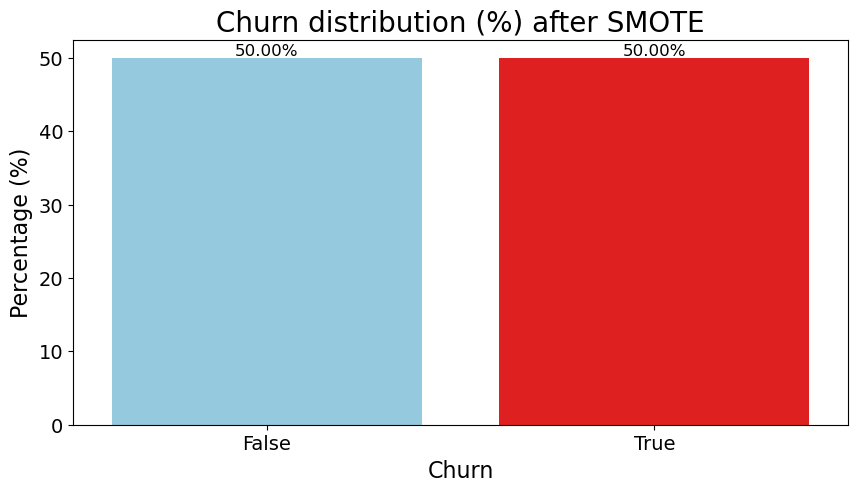

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

# Get percentage distribution
churn_percent = y_train_resampled.value_counts(normalize=True).reset_index()
churn_percent.columns = ['Churn', 'Percentage']
churn_percent['Percentage'] = churn_percent['Percentage'] * 100

sns.barplot(
    data=churn_percent,
    x='Churn',
    y='Percentage',
    palette=['skyblue', 'red'],
    ax=ax
)

ax.set_title('Churn distribution (%) after SMOTE', fontsize=20)
ax.set_xlabel('Churn', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.show()

The distribution of the churn classes is now balanced. SMOTE was applied on the training sets only. This ensured that an accurate gauge can be made on the model's performance by using a raw test sample that has not been oversampled or undersampled.

### Modeling
### 1. Logistic regression
Logistic regression model will be used as the baseline model.

In [33]:
# create a pipeline
from sklearn.pipeline import Pipeline
pipe_log = Pipeline(steps=[('scale', StandardScaler()), ('logreg', LogisticRegression(fit_intercept=False, solver='liblinear'))])
pipe_log.fit(X_train_resampled, y_train_resampled)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [34]:
# function to evaluate the performance of the model
def evaluate(model, X_test, y_test):
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    print('Recall_score: ')
    print('Train: ', recall_score(y_train_resampled, y_train_pred))
    print('Test: ', recall_score(y_test, y_test_pred))
    print('\nPrecision_score: ')
    print('Train: ', precision_score(y_train_resampled, y_train_pred))
    print('Test: ', precision_score(y_test, y_test_pred))
    print('\nAccuracy_score: ')
    print('Train: ', accuracy_score(y_train_resampled, y_train_pred))
    print('Test: ', accuracy_score(y_test, y_test_pred))
    print('\nClassification Report:')
    print(classification_report(y_test, y_test_pred))
    cm = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot();

Recall_score: 
Train:  0.849357554275587
Test:  0.22972972972972974

Precision_score: 
Train:  0.9696509863429439
Test:  0.40476190476190477

Accuracy_score: 
Train:  0.9113867966326983
Test:  0.8770614692653673

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.93       593
        True       0.40      0.23      0.29        74

    accuracy                           0.88       667
   macro avg       0.66      0.59      0.61       667
weighted avg       0.85      0.88      0.86       667



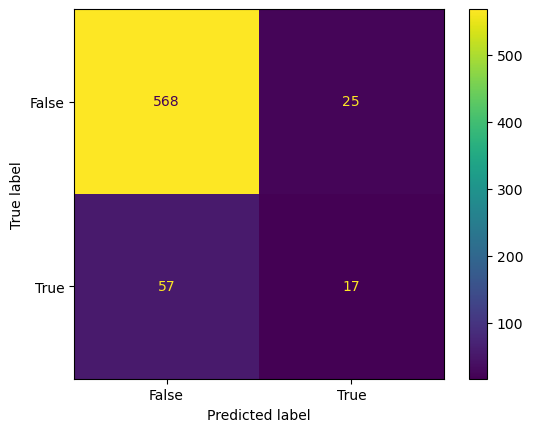

In [35]:
# evaluate the performance of the model
evaluate(pipe_log, X_test, y_test)

## Interpreation of the results
The model is overfitting as it performs well on the training data but does not perform well on the test data. Despite the model having a high accuracy on the test data(0.87), it has a very low recall score(0.22). The model is thus performing poorly due to the large number of false negatives.
Test precision is also poor as it only predicts only 40% of the time.
### Confusion Matrix interpretation
#### Breakdown of the values
* True Negatives (TN) = 568
The model correctly predicted False (no churn).
* False Positives (FP) = 25
The model incorrectly predicted True (churn) when it was actually False.
* False Negatives (FN) = 57
The model missed actual churn cases (predicted False when it was True).
* True Positives (TP) = 17
The model correctly predicted True (churn).
#### What this means
1. The model is very good at predicting the majority class (False)
568 correct negatives is high.
This suggests the model is strong at identifying customers who do NOT churn.
2. Weak performance on the positive class (churn)
Only 17 true positives vs 57 false negatives
This means the model is missing many churners.
3. Recall for churn is low

Recall (for churn) = TP / (TP + FN)
= 17 / (17 + 57) ≈ 0.23

So the model only catches about 23% of actual churners, which is quite low.

4. Precision is moderate

Precision = TP / (TP + FP)
= 17 / (17 + 25) ≈ 0.40

So when it predicts churn, it's right about 40% of the time.


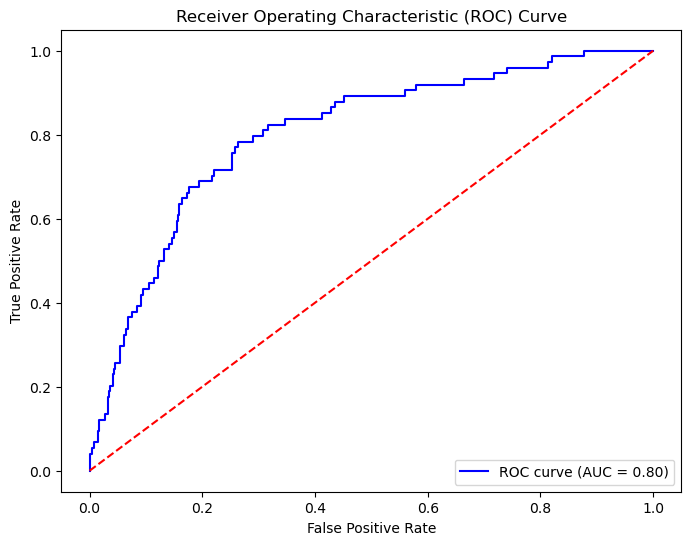

In [36]:
# Plot ROC curve and calculate AUC
y_test_probs = pipe_log.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs) 
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random classifier
plt.title('Receiver Operating Characteristic (ROC) Curve') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


### Results interpretation:

* AUC = 0.80: This is a strong indicator that the model has good predictive power.
It means there is about an 80% chance the model will rank a randomly chosen positive example higher than a negative one.
* Curve shape (blue line):
The curve is well above the diagonal red dashed line (which represents a random classifier with AUC = 0.5). This confirms the model is learning meaningful patterns rather than guessing.
* TPR and FPR:
As you move right, the True Positive Rate (recall) increases.
But the False Positive Rate also increases.
The curve shows a reasonable balance—especially in the middle region where TPR improves quickly without too much increase in FPR.

### 2. Decision Tree.
Decision Tree Classifier is a non-parametric supervised learning method used for classification and regression tasks.

In [37]:
# Create a pipeline for Decision Tree Classifier
pipe_tree = Pipeline(steps=[('scale', StandardScaler()), ('clf', DecisionTreeClassifier(criterion='entropy', random_state=42))])
pipe_tree.fit(X_train_resampled, y_train_resampled)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


Recall_score: 
Train:  1.0
Test:  0.8243243243243243

Precision_score: 
Train:  1.0
Test:  0.5041322314049587

Accuracy_score: 
Train:  1.0
Test:  0.8905547226386806

Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.90      0.94       593
        True       0.50      0.82      0.63        74

    accuracy                           0.89       667
   macro avg       0.74      0.86      0.78       667
weighted avg       0.92      0.89      0.90       667



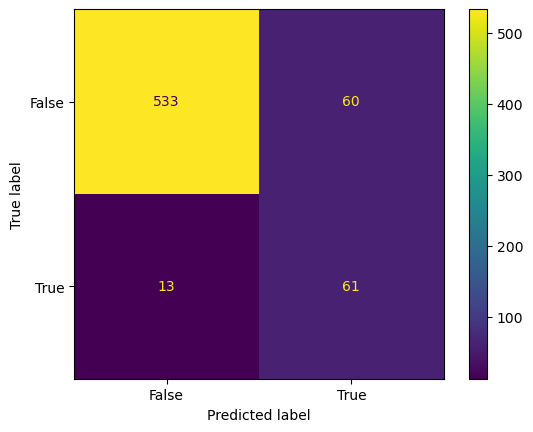

In [38]:
# Evaluate the Decision Tree model
evaluate(pipe_tree, X_test, y_test)


### Results interpretation
* The model performs perfectly on training data at 100% but slightly drops on test data at 86%. This suggests some overfitting.
* The model is very good at finding customers who will churn (high recall).
* But it also flags some customers incorrectly as churners (lower precision).

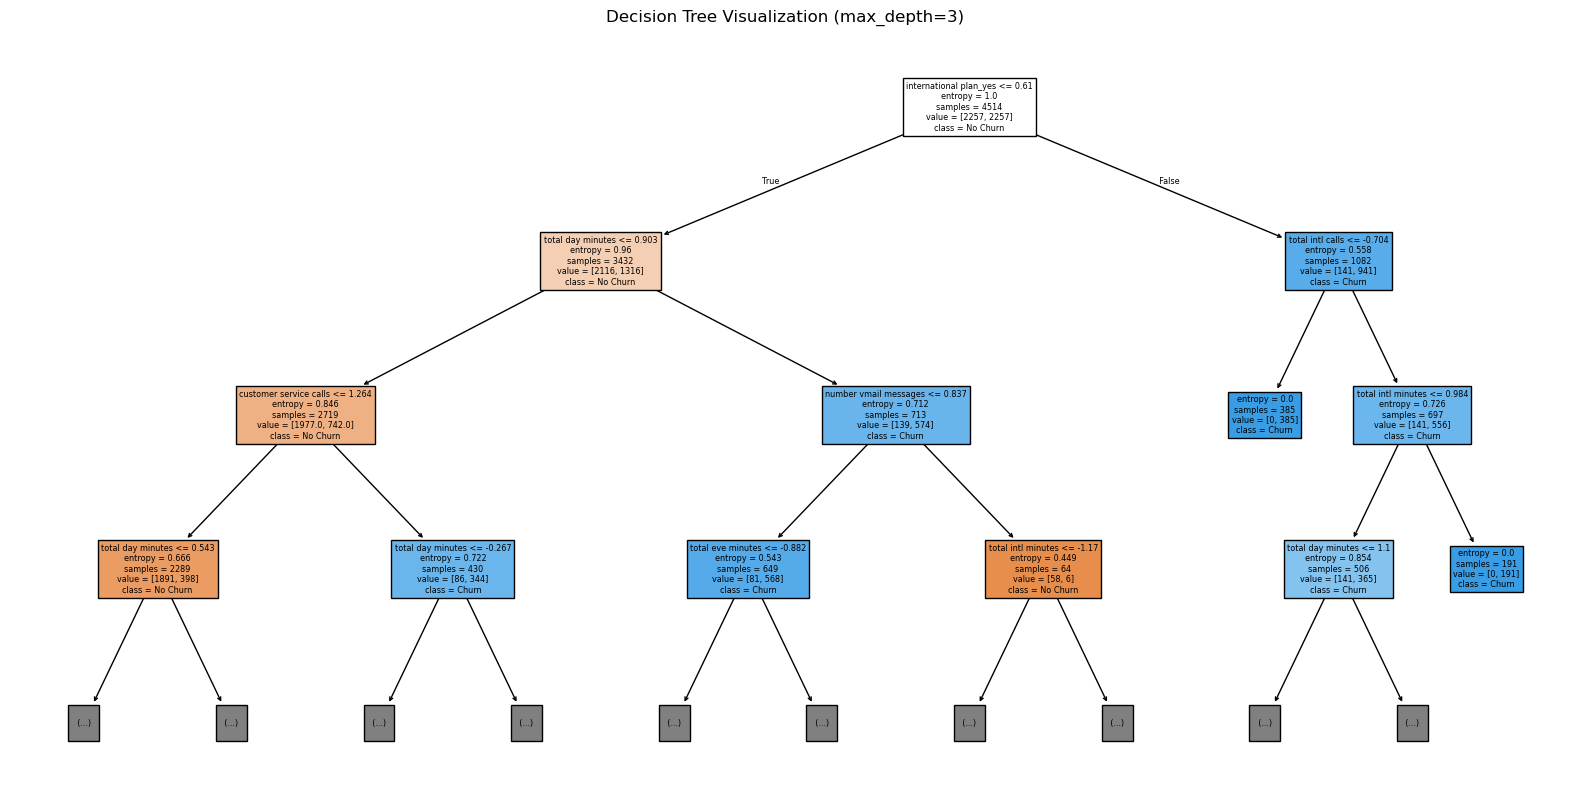

In [39]:
# Visualize the Decision Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(pipe_tree.named_steps['clf'], filled=True, feature_names=X_train_resampled.columns, class_names=['No Churn', 'Churn'], max_depth=3)
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()


## Feature importances.

In [40]:
# Feature importance from the Decision Tree model
feature_importances = pipe_tree.named_steps['clf'].feature_importances_
feature_names = X_train_resampled.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False) 
print(feature_importance_df.head(10))


                   Feature  Importance
3        total day minutes    0.227270
62  international plan_yes    0.135951
11  customer service calls    0.117901
5        total eve minutes    0.099887
9       total intl minutes    0.055002
2    number vmail messages    0.051855
7      total night minutes    0.049075
0           account length    0.036929
6          total eve calls    0.030971
10        total intl calls    0.030886


C:\Users\Stephen\AppData\Local\Temp\ipykernel_26400\474341598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


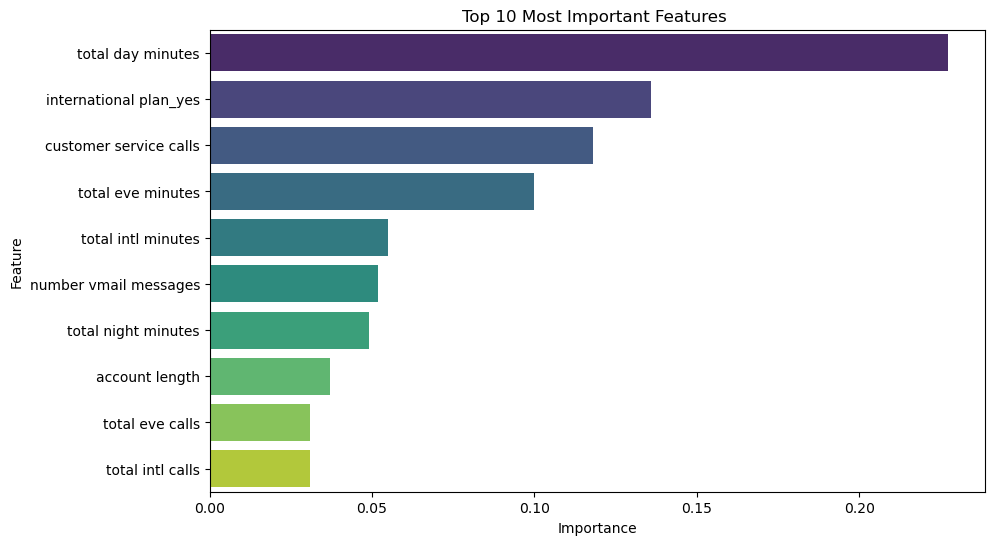

In [ ]:
# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

 total day calls, total eve calls, total night calls, and customer service calls are the most important features in predicting customer churn according to the Decision Tree model.

In [42]:
# Feature selection using Recursive Feature Elimination with Cross-Validation (RFECV)
rfecv = RFECV(estimator=DecisionTreeClassifier(random_state=42),scoring='recall')
pipe_tree1 = Pipeline(steps=[('scale', StandardScaler()), ('Feature Selection', rfecv), ('clf', DecisionTreeClassifier(random_state=42))])
pipe_tree1.fit(X_train_resampled, y_train_resampled)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('Feature Selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,DecisionTreeC...ndom_state=42)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.mode

In [43]:
# optimal number of features selected via cross-validation
print(f'Optimal number of features: {rfecv.n_features_}' )

Optimal number of features: 55


In [44]:
# selected features (assigned a rank of 1)
rfecv_df = pd.DataFrame(rfecv.ranking_,index=X_train_resampled.columns,columns=['Rank']).sort_values(by='Rank',ascending=True)
rfecv_df[rfecv_df['Rank'] == 1]

,Rank
account length,1
area code,1
number vmail messages,1
total day minutes,1
total day calls,1
total eve minutes,1
total eve calls,1
total night minutes,1
total night calls,1
total intl minutes,1


In [45]:
# remove columns that are not part of the optimal features
cols = rfecv_df[rfecv_df['Rank'] == 1].index
X_train_resampled = X_train_resampled[cols]
X_test = X_test[cols]
X_train_resampled.head(2)

,account length,area code,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,...,state_OK,state_PA,state_OR,international plan_yes,state_WY,state_WA,state_WI,voice mail plan_yes,state_VA,state_UT
0,95,510,0,157.3,116,197.5,77,128.2,111,8.4,...,False,False,False,False,False,False,False,False,False,False
1,52,408,31,142.1,77,193.0,97,253.4,88,11.0,...,False,False,False,False,False,False,False,True,False,False


### Hyperparameter tuning of the Decision tree

In [46]:
# hyperparameter tuning using GridSearchCV
params_dt = {'clf__criterion': ['gini', 'entropy'],
             'clf__max_depth': range(14, 32, 2),
             'clf__min_samples_split' : range(2, 10, 2),
             'clf__min_samples_leaf': [2, 3, 5, 7, 10],
             'clf__max_features': [11, 13, 15]
}

gridsearch_dt = GridSearchCV(pipe_tree, params_dt, cv=4, scoring='recall')
gridsearch_dt.fit(X_train_resampled, y_train_resampled)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__criterion': ['gini', 'entropy'], 'clf__max_depth': range(14, 32, 2), 'clf__max_features': [11, 13, ...], 'clf__min_samples_leaf': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computa

In [47]:
print(f"Best parameters: {gridsearch_dt.best_params_}")
print(f"Best recall score from GridSearchCV: {gridsearch_dt.best_score_:.4f}")

Best parameters: {'clf__criterion': 'entropy', 'clf__max_depth': 24, 'clf__max_features': 15, 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 2}
Best recall score from GridSearchCV: 0.8994


Recall_score: 
Train:  0.9689853788214444
Test:  0.7297297297297297

Precision_score: 
Train:  0.9798387096774194
Test:  0.4426229508196721

Accuracy_score: 
Train:  0.9745237040319008
Test:  0.8680659670164917

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92       593
        True       0.44      0.73      0.55        74

    accuracy                           0.87       667
   macro avg       0.70      0.81      0.74       667
weighted avg       0.91      0.87      0.88       667



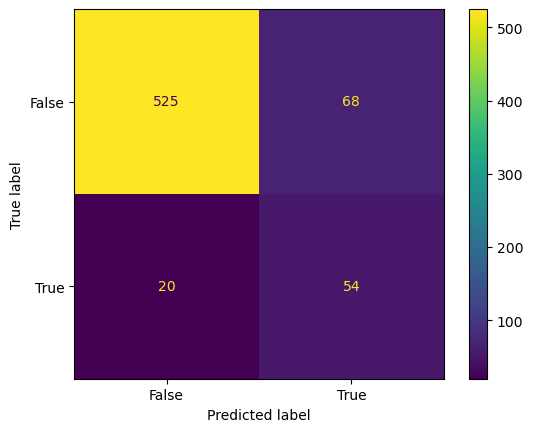

In [48]:
# Evaluate the performance of the best Decision Tree model from GridSearchCV
evaluate(gridsearch_dt, X_test, y_test)

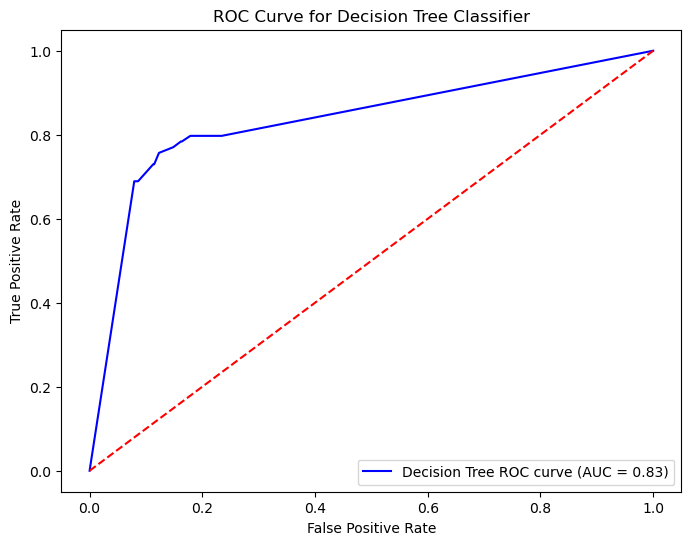

In [49]:
# Plot ROC curve and calculate AUC for Decision Tree
y_test_probs_dt = gridsearch_dt.predict_proba(X_test)[:, 1] 
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_test_probs_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='blue', label=f'Decision Tree ROC curve (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curve for Decision Tree Classifier') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

### Results interpretation
The model is performing better after hyperparameter tuning,  based on the recall score of 73%. This is a strong performance for churn predictiob.
However, the precision score is slightly low. There is a decrease in the difference between the train scores and the test scores(overfitting reduced).

### Random Forest Classifier
A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

In [50]:
# Random Forest Classifier
pipe_rf = Pipeline(steps=[('scale', StandardScaler()), ('rf', RandomForestClassifier(random_state=42))])
# Fit the Random Forest model on the resampled training data
pipe_rf.fit(X_train_resampled, y_train_resampled)   

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


Recall_score: 
Train:  1.0
Test:  0.7702702702702703

Precision_score: 
Train:  1.0
Test:  0.5816326530612245

Accuracy_score: 
Train:  1.0
Test:  0.9130434782608695

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.93      0.95       593
        True       0.58      0.77      0.66        74

    accuracy                           0.91       667
   macro avg       0.78      0.85      0.81       667
weighted avg       0.93      0.91      0.92       667



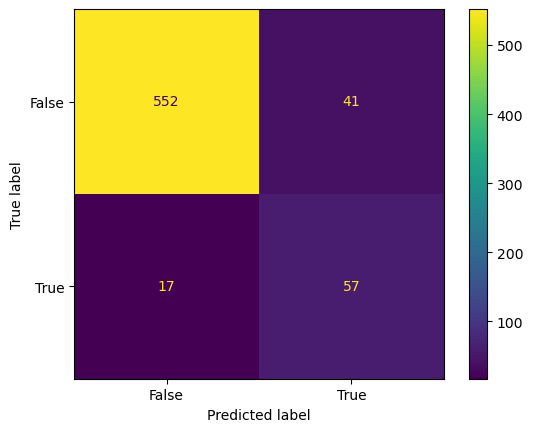

In [51]:
# Evaluate the performance of the Random Forest model
evaluate(pipe_rf, X_test, y_test)

### Results interpretation
The recall is 77% which is a strong churn prediction.The precicion is also better at 58%

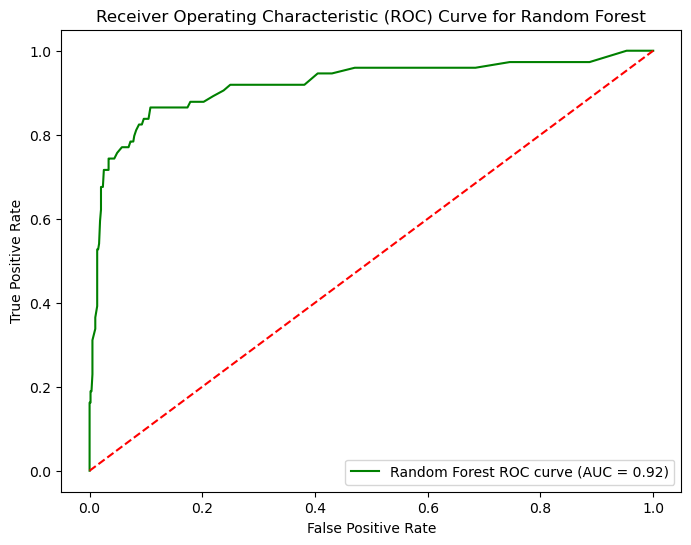

In [52]:
# Plot ROC curve and calculate AUC for Random Forest
y_test_probs_rf = pipe_rf.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_test_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)   
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random classifier
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')    
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


### Results interpretation
The AUC is 0.92 which is actually very good.

### Hyperparameter tuning of Random forest model
Hyperparameter tuning for Random Forest using RandomizedSearchCV. We will use RandomizedSearchCV instead of GridSearchCV for Random Forest due to the larger number of hyperparameters and their possible values, which can lead to a combinatorial explosion in the number of models to train.

In [53]:
#  RandomizedSearchCV allows us to sample a fixed number of hyperparameter combinations,
#  making it more efficient while still providing good results.
from sklearn.model_selection import RandomizedSearchCV
pipe_rf = Pipeline([
    ('rf', RandomForestClassifier(random_state=200))
])

params_rf = {
    'rf__n_estimators': [100, 200, 400],
    'rf__max_depth': [5, 10, 15, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__criterion': ['gini', 'entropy']
}

randomsearch_rf = RandomizedSearchCV(
    pipe_rf,
    params_rf,
    n_iter=30,       # only 30 combinations tested
    cv=4,
    scoring='recall',
    n_jobs=-1,
    random_state=200
)

randomsearch_rf.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:", randomsearch_rf.best_params_)
print("Best CV Recall:", randomsearch_rf.best_score_)

Best Parameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': None, 'rf__criterion': 'gini'}
Best CV Recall: 0.9521480574907426


Recall_score: 
Train:  0.9986708019494904
Test:  0.7162162162162162

Precision_score: 
Train:  1.0
Test:  0.5955056179775281

Accuracy_score: 
Train:  0.9993354009747453
Test:  0.9145427286356822

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.94      0.95       593
        True       0.60      0.72      0.65        74

    accuracy                           0.91       667
   macro avg       0.78      0.83      0.80       667
weighted avg       0.92      0.91      0.92       667



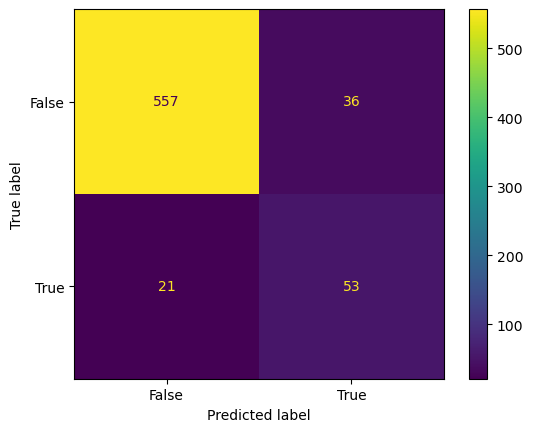

In [54]:
# evaluate the performance of the model
evaluate(randomsearch_rf, X_test, y_test)

### Results interpretation
The model correctly identifies about 72% of actual churners, correctly predicts 0.59% of the time and an accuracy score of 92%

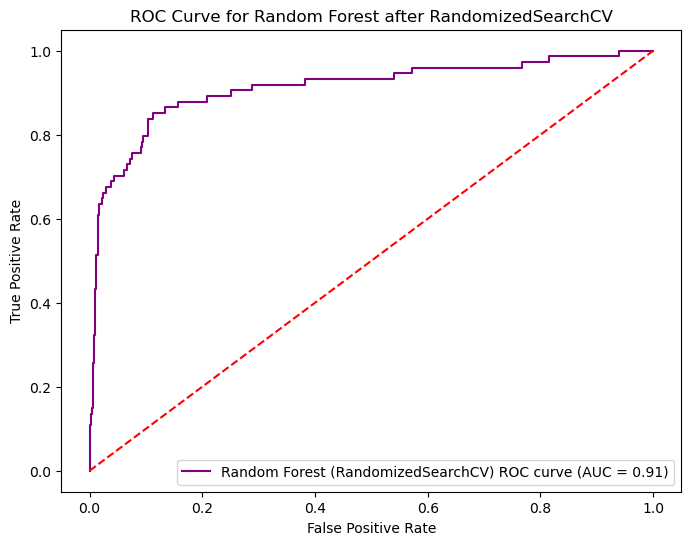

In [55]:
# Plot ROC curve and calculate AUC for Random Forest after RandomizedSearchCV
y_test_probs_rf_rs = randomsearch_rf.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr_rf_rs, tpr_rf_rs, thresholds_rf_rs = roc_curve(y_test, y_test_probs_rf_rs)
roc_auc_rf_rs = auc(fpr_rf_rs, tpr_rf_rs)   
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_rs, tpr_rf_rs, color='purple', label=f'Random Forest (RandomizedSearchCV) ROC curve (AUC = {roc_auc_rf_rs:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curve for Random Forest after RandomizedSearchCV')   
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

### Results interpretation
AUC is 0.91 for the Random Forest model after hyperparameter tuning with RandomizedSearchCV,  which indicates excellent model performance in distinguishing between the classes.

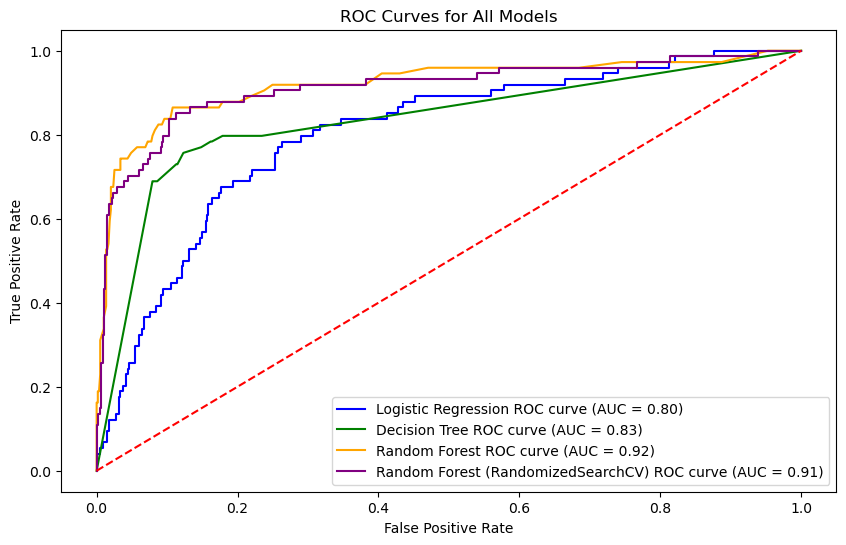

In [56]:
# Plot AUC and compare all models
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression ROC curve (AUC = {roc_auc:.2f})')
plt.plot(fpr_dt, tpr_dt, color='green', label=f'Decision Tree ROC curve (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='orange', label=f'Random Forest ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_rf_rs, tpr_rf_rs, color='purple', label=f'Random Forest (RandomizedSearchCV) ROC curve (AUC = {roc_auc_rf_rs:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curves for All Models') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc= 'lower right')
plt.show()

In [61]:
model_comparison = pd.DataFrame({'Model':['Logistic Regression',
                                          'Decision Trees Classifier',
                                          'Random Forest Classifier'],
                                 'Accuracy (Test Set)':[0.91,0.89,0.91],
                                 'F1 Score (Test Set)':[0.29,0.63,0.66],
                                 'Recall (Test Set)':[0.22,0.82,0.77],
                                 'Precision (Test Set)':[0.40,0.50,0.58]})

model_comparison.style.highlight_max(color = 'grey', axis = 0)

,Model,Accuracy (Test Set),F1 Score (Test Set),Recall (Test Set),Precision (Test Set)
0,Logistic Regression,0.910000,0.290000,0.220000,0.400000
1,Decision Trees Classifier,0.890000,0.630000,0.820000,0.500000
2,Random Forest Classifier,0.910000,0.660000,0.770000,0.580000


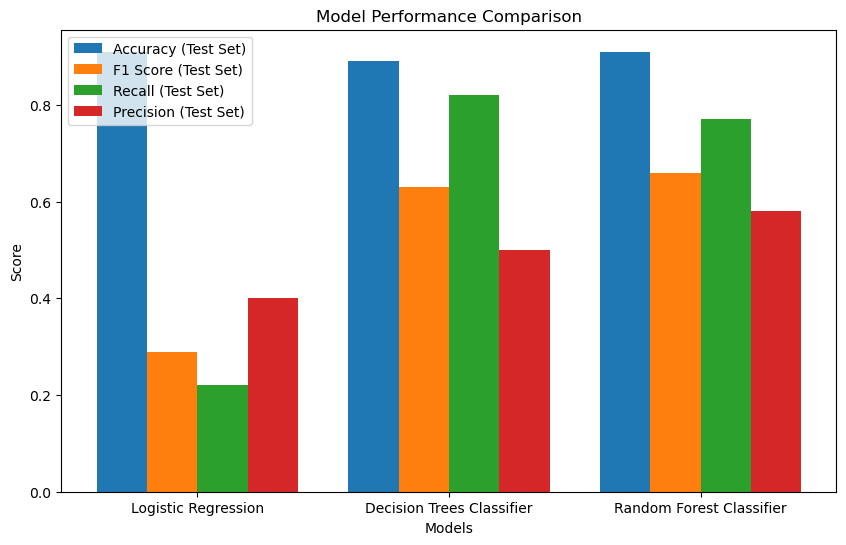

In [ ]:
# Plot a bar graph to compare the models performance
metrics = ['Accuracy (Test Set)', 'F1 Score (Test Set)', 'Recall (Test Set)', 'Precision (Test Set)']
models = model_comparison['Model']

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, model_comparison[metric], width, label=metric)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models)
ax.legend()

plt.show()

### Conclusion
The analysis of the dataset indicates that customer churn can be effectively predicted using machine learning models. Of the models evaluated, the Random Forest Classifier is recommended as it shows the strongest overall performance. It achieves a higher ROC curve that closely approaches the top-left corner, reflecting a high AUC (Area Under the Curve) and strong ability to distinguish between churn and non-churn customers.

Based on these results, it is recommended that Syriatel adopt the Random Forest Classifier as the primary model for churn prediction. This model performs consistently well across key evaluation metrics, including accuracy, F1-score, recall, and precision on the test set, making it a reliable choice for identifying customers who are at risk of leaving.

Key features influencing customer churn include:
* Total day minutes: total duration of daytime calls
* Total evening minutes: total duration of evening calls
* Customer service calls: number of interactions with customer support
* Total international minutes: total duration of international calls

### Business recommendations for Syriatel

From a strategic perspective, Syriatel should implement customer retention initiatives that target the key drivers of churn, particularly those related to call usage and pricing. This may include offering personalized discounts or more competitive rates for daytime usage to encourage continued customer engagement and reduce attrition.

In addition, the company should focus on improving customer service efficiency and satisfaction. Since the number of customer service calls is a significant predictor of churn, reducing the need for repeated or unresolved support interactions could help improve customer experience and retention.

Overall, by addressing these key factors, Syriatel can reduce churn rates, strengthen customer loyalty, and minimize revenue loss.